# TASK 5 – Sales Prediction Using Python

## Objective
Build regression models to predict **Sales** from advertising spend across **TV, Radio, and Newspaper** channels.

### Models
1. Linear Regression — baseline
2. Random Forest Regressor — additional model
3. Polynomial Regression — additional model

### Evaluation
- MAE
- RMSE
- R² score
- Residual analysis
- Feature importance / coefficients

> **Dataset:** Advertising dataset with TV, Radio, Newspaper and Sales columns.


## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load the Dataset

The code below loads the classic `Advertising.csv` dataset directly from a public GitHub copy of the ISLR dataset.

If your instructor has provided a local `Advertising.csv`, you can replace the URL with:

```python
df = pd.read_csv("Advertising.csv")
```


In [2]:
DATA_URL = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/refs/heads/master/Notebooks/Data/Advertising.csv"

df = pd.read_csv(DATA_URL)

# Remove the old index column present in this copy of the dataset
if df.columns[0] == "" or df.columns[0].lower().startswith("unnamed"):
    df = df.drop(columns=df.columns[0])

df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 3. Basic Dataset Information and EDA

In [3]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe())


Shape: (200, 4)

Column names:
['TV', 'Radio', 'Newspaper', 'Sales']

Data types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0

Descriptive statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### Pairplot of All Features

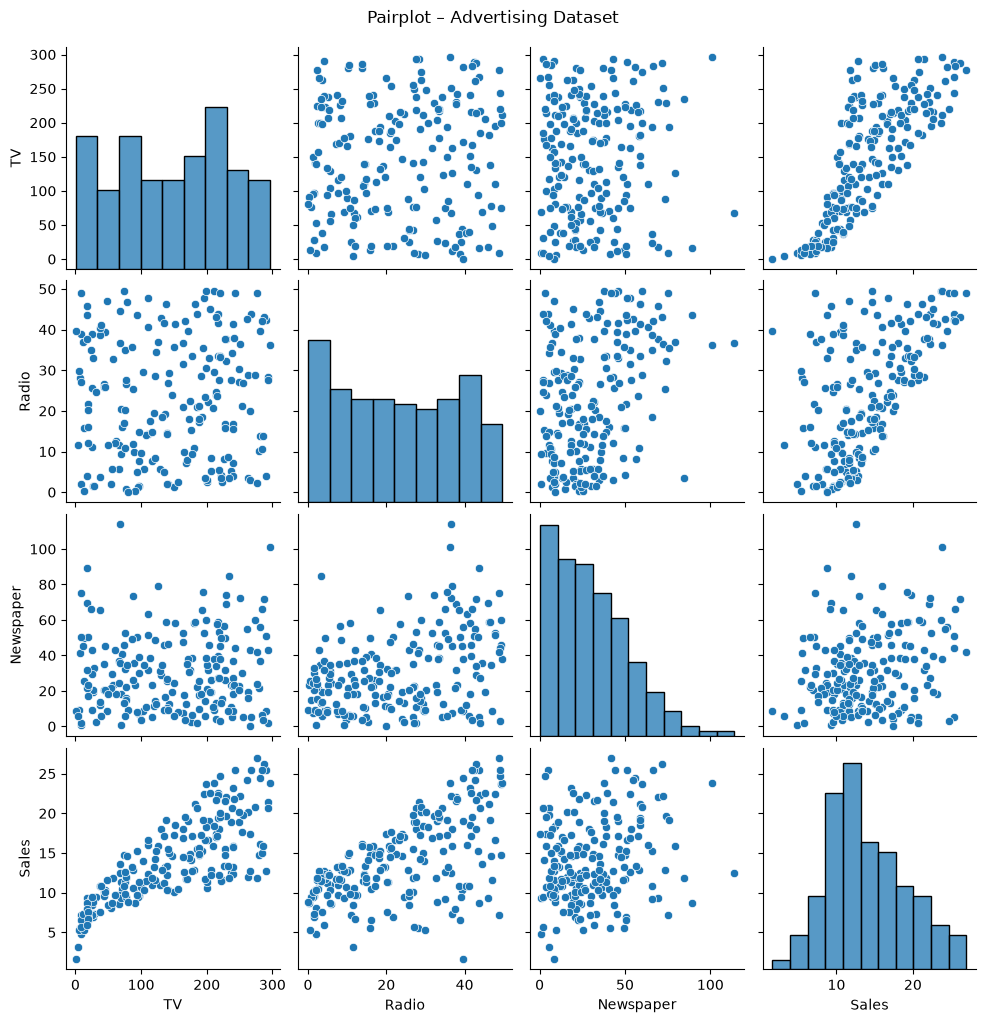

In [4]:
sns.pairplot(df)
plt.suptitle("Pairplot – Advertising Dataset", y=1.02)
plt.show()


### Individual Scatter Plots

These plots show the relationship between each advertising channel and Sales.


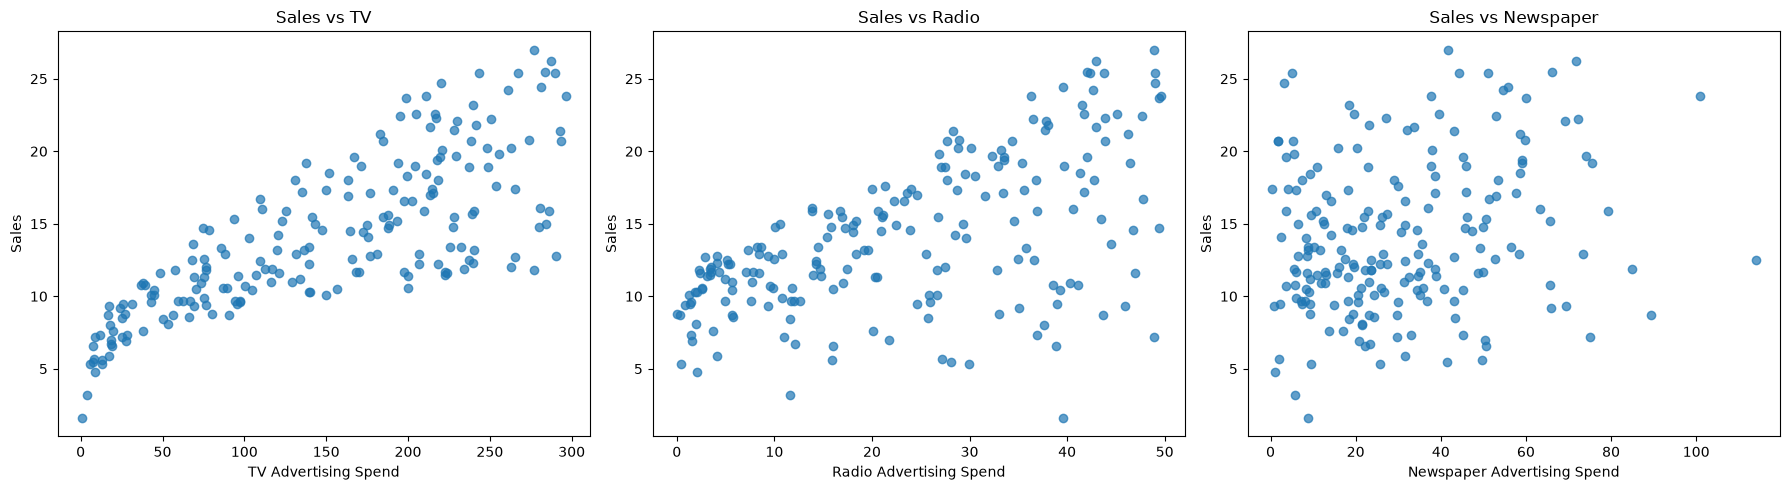

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

channels = ["TV", "Radio", "Newspaper"]

for ax, channel in zip(axes, channels):
    ax.scatter(df[channel], df["Sales"], alpha=0.7)
    ax.set_xlabel(f"{channel} Advertising Spend")
    ax.set_ylabel("Sales")
    ax.set_title(f"Sales vs {channel}")

plt.tight_layout()
plt.show()


### Correlation Matrix Heatmap

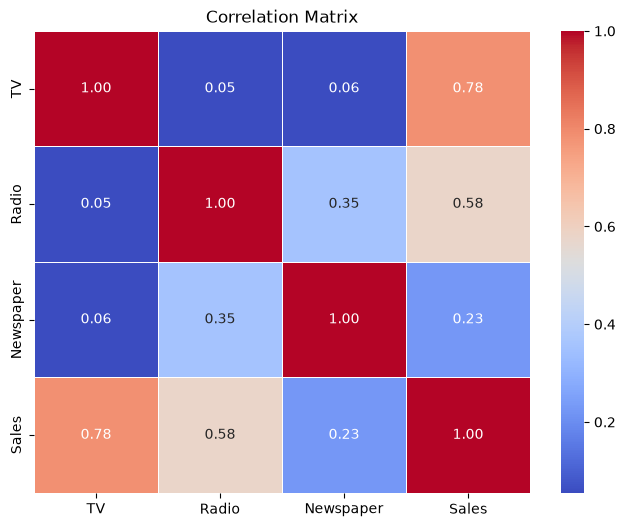

In [6]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


## 4. Prepare Features and Target

- **X** = TV, Radio, Newspaper advertising spend
- **y** = Sales
- 80% data is used for training and 20% for testing.
- `random_state=42` makes the split reproducible.


In [7]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 160
Testing samples : 40


## 5. Evaluation Function

In [8]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }, predictions


## 6. Baseline Model – Linear Regression

In [9]:
linear_model = LinearRegression()

linear_result, linear_pred = evaluate_model(
    "Linear Regression",
    linear_model,
    X_train, X_test, y_train, y_test
)

print("Linear Regression Results")
print(f"MAE      : {linear_result['MAE']:.4f}")
print(f"RMSE     : {linear_result['RMSE']:.4f}")
print(f"R² Score : {linear_result['R2 Score']:.4f}")

print("\nLinear Regression Coefficients:")
for feature, coef in zip(X.columns, linear_model.coef_):
    print(f"{feature:10s}: {coef:.4f}")

print(f"Intercept  : {linear_model.intercept_:.4f}")


Linear Regression Results
MAE      : 1.4608
RMSE     : 1.7816
R² Score : 0.8994

Linear Regression Coefficients:
TV        : 0.0447
Radio     : 0.1892
Newspaper : 0.0028
Intercept  : 2.9791


## 7. Additional Model – Random Forest Regressor

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

rf_result, rf_pred = evaluate_model(
    "Random Forest Regressor",
    rf_model,
    X_train, X_test, y_train, y_test
)

print("Random Forest Results")
print(f"MAE      : {rf_result['MAE']:.4f}")
print(f"RMSE     : {rf_result['RMSE']:.4f}")
print(f"R² Score : {rf_result['R2 Score']:.4f}")


Random Forest Results
MAE      : 0.6139
RMSE     : 0.7406
R² Score : 0.9826


## 8. Additional Model – Polynomial Regression

A degree-2 polynomial model is used to capture possible nonlinear relationships.


In [11]:
poly_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_regression", LinearRegression())
])

poly_result, poly_pred = evaluate_model(
    "Polynomial Regression (Degree 2)",
    poly_model,
    X_train, X_test, y_train, y_test
)

print("Polynomial Regression Results")
print(f"MAE      : {poly_result['MAE']:.4f}")
print(f"RMSE     : {poly_result['RMSE']:.4f}")
print(f"R² Score : {poly_result['R2 Score']:.4f}")


Polynomial Regression Results
MAE      : 0.5262
RMSE     : 0.6426
R² Score : 0.9869


## 9. Compare All Models

In [12]:
results = pd.DataFrame([
    linear_result,
    rf_result,
    poly_result
])

results = results.sort_values("RMSE").reset_index(drop=True)
display(results.style.format({
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R2 Score": "{:.4f}"
}))

best_model_name = results.iloc[0]["Model"]
print("Best model based on lowest RMSE:", best_model_name)


,Model,MAE,RMSE,R2 Score
0,Polynomial Regression (Degree 2),0.5262,0.6426,0.9869
1,Random Forest Regressor,0.6139,0.7406,0.9826
2,Linear Regression,1.4608,1.7816,0.8994


Best model based on lowest RMSE: Polynomial Regression (Degree 2)


## 10. Actual vs Predicted Sales for the Best Model

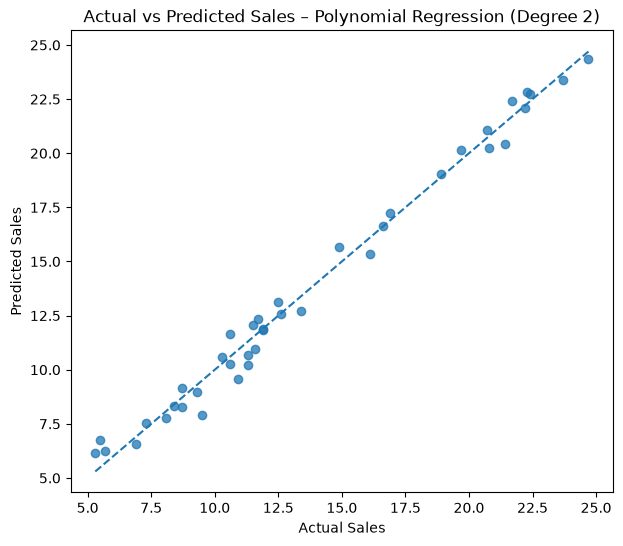

In [13]:
prediction_map = {
    "Linear Regression": linear_pred,
    "Random Forest Regressor": rf_pred,
    "Polynomial Regression (Degree 2)": poly_pred
}

best_pred = prediction_map[best_model_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.75)

min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales – {best_model_name}")
plt.show()


## 11. Residual Plot

Residual = Actual Sales − Predicted Sales.

A good regression model should have residuals scattered around zero without a clear curve or systematic pattern.


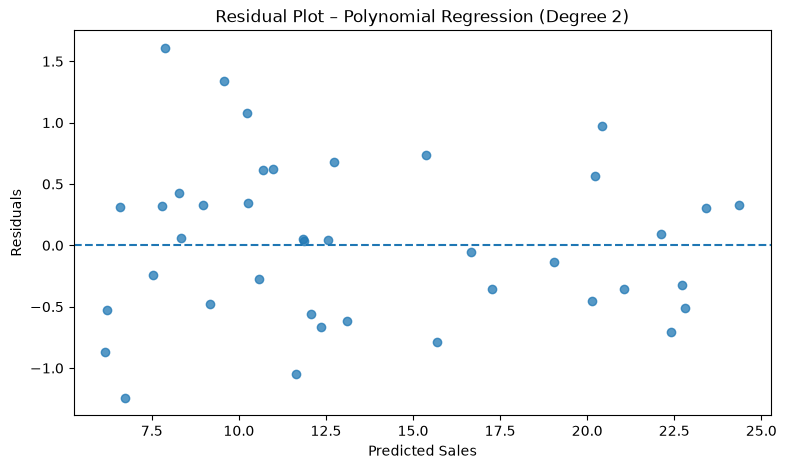

Mean residual: 0.016831275800979806


In [14]:
residuals = y_test - best_pred

plt.figure(figsize=(9, 5))
plt.scatter(best_pred, residuals, alpha=0.75)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title(f"Residual Plot – {best_model_name}")
plt.show()

print("Mean residual:", residuals.mean())


## 12. Feature Importance / Interpretation

For Random Forest, feature importance indicates the relative contribution of each advertising channel to prediction.

For Linear Regression, coefficients indicate the expected change in Sales for a one-unit increase in a channel while the other channels are held constant.

We display both so the interpretation is easy to discuss in the report.


Random Forest Feature Importance:


,Importance
TV,0.625448
Radio,0.361751
Newspaper,0.012801


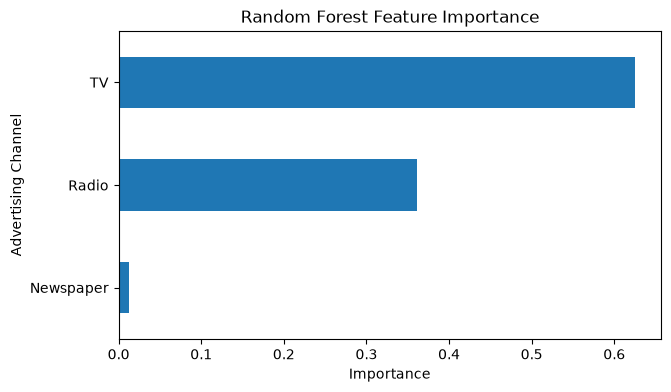

Linear Regression Coefficients:


,Feature,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


In [15]:
# Random Forest feature importance
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
display(rf_importance.to_frame("Importance"))

plt.figure(figsize=(7, 4))
rf_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")
plt.title("Random Forest Feature Importance")
plt.show()

# Linear Regression coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Linear Regression Coefficients:")
display(coef_df)


## 13. Final Interpretation / Discussion

### Findings to report

1. **Data quality:** Check the null-value output. The standard Advertising dataset is clean and contains numeric variables.
2. **Relationship with Sales:** TV and Radio generally show stronger relationships with Sales than Newspaper.
3. **Model comparison:** Use the generated MAE, RMSE and R² table. Lower MAE/RMSE and higher R² indicate better performance.
4. **Residuals:** The residual plot should be checked for random scatter around zero. A visible curve or funnel shape may indicate model limitations.
5. **Most influential channel:** Use the Random Forest feature-importance table and Linear Regression coefficients. The feature with the largest importance / strongest coefficient is the strongest predictor in this model.
6. **Business interpretation:** Advertising budget can be allocated preferentially toward channels that demonstrate stronger predictive influence, while remembering that correlation/prediction does not by itself prove causation.


## 14. Example Prediction for a New Advertising Budget

Change the values below to predict Sales for a new advertising plan.


In [16]:
new_campaign = pd.DataFrame({
    "TV": [200],
    "Radio": [30],
    "Newspaper": [20]
})

print("Predicted Sales:")
print(f"Linear Regression   : {linear_model.predict(new_campaign)[0]:.2f}")

# Random Forest
print(f"Random Forest       : {rf_model.predict(new_campaign)[0]:.2f}")

# Polynomial Regression
print(f"Polynomial Regression: {poly_model.predict(new_campaign)[0]:.2f}")


Predicted Sales:
Linear Regression   : 17.66
Random Forest       : 18.29
Polynomial Regression: 18.40


# Conclusion

The project successfully builds and compares multiple regression models for Sales Prediction using TV, Radio, and Newspaper advertising expenditure.

The final model should be selected using the test-set metrics rather than assuming one algorithm is always best. The residual plot and feature-importance/coefficient analysis provide additional evidence for the final discussion.
